In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from keras import Sequential
from keras._tf_keras.keras.models import load_model
from keras._tf_keras.keras.layers import GRU, Dense
import joblib

In [13]:
# Read preprocessed data
df = pd.read_csv("Preprocessed_MCD.csv")

In [14]:
# Confirmation of test date position
start_val = int((len(df)-100)*0.8)+100
end_val = int((len(df)-100)*0.9)+100
print(start_val)
print(end_val)

df["Date"][start_val:end_val]

1026
1142


1026    2023-11-30
1027    2023-12-01
1028    2023-12-04
1029    2023-12-05
1030    2023-12-06
           ...    
1137    2024-05-10
1138    2024-05-13
1139    2024-05-14
1140    2024-05-15
1141    2024-05-16
Name: Date, Length: 116, dtype: object

In [15]:
X = df[["High", "Low", "Open", "Volume"]]
y = df["Close"]
print(X.shape)
print(y.shape)

#scaling
scale_X = MinMaxScaler()
scale_y = MinMaxScaler()
normalised_X = scale_X.fit_transform(X)
normalised_y = scale_y.fit_transform(y.values.reshape(-1, 1))

input_size = 100
X_temp, y_temp = [], []
X_train, y_train = [], []
X_test, y_test = [], []
X_val, y_val = [], []
#loop to append the scaled data for each consecutive 100 days (Ex: 1-100th day, 2-101st day, etc) into the empty temp list
for i in range(input_size, len(normalised_X)):
    X_temp.append(normalised_X[i-input_size:i, 0:4])
    y_temp.append(normalised_y[i, 0])

#converted to numpy arrays for easy access
X_temp, y_temp = np.array(X_temp), np.array(y_temp)
print(X_temp.shape)
print(y_temp.shape)

# Data splitting
train_index = int(0.8*len(X_temp))
test_index = int(0.9*len(X_temp))

X_train, X_val, X_test = X_temp[:train_index], X_temp[train_index:test_index], X_temp[test_index:]
y_train, y_val, y_test = y_temp[:train_index], y_temp[train_index:test_index], y_temp[test_index:]

print("X_train shape: ", X_train.shape, "\ty_train shape: ", y_train.shape)
print("X_val shape: ", X_val.shape, "\ty_val shape: ", y_val.shape)
print("X_test shape: ", X_test.shape, "\ty_test shape: ", y_test.shape)

(1258, 4)
(1258,)
(1158, 100, 4)
(1158,)
X_train shape:  (926, 100, 4) 	y_train shape:  (926,)
X_val shape:  (116, 100, 4) 	y_val shape:  (116,)
X_test shape:  (116, 100, 4) 	y_test shape:  (116,)


In [16]:
trained_GRU = "Saved_GRU_Model.h5"

def building_GRU(X_train):
    if os.path.exists(trained_GRU):
        #compile the model when model is exist
        print("Loading trained GRU model.....")
        GRU_model = load_model("Saved_GRU_Model.h5")
        GRU_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
        GRU_model.summary()
    else:
        print("Building GRU model.....")
        # Model construction
        GRU_model = Sequential()
        # GRU layers
        GRU_model.add(GRU(units=64, input_shape=(X_train.shape[1], X_train.shape[2]), activation="relu", return_sequences=True))
        GRU_model.add(GRU(units=64, activation="relu", return_sequences=True))
        GRU_model.add(GRU(units=64, activation="relu", return_sequences=True))
        GRU_model.add(GRU(units=64, activation="relu"))
        # Final layer
        GRU_model.add(Dense(units=1))
        # Compile model
        GRU_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
        GRU_model.summary()
    return GRU_model

GRU_model = building_GRU(X_train)

Loading trained GRU model.....


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 64)        │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,385 (345.25 KB)

 Trainable params: 88,385 (345.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def fitting_GRU(GRU_model, X_train, y_train, X_val, y_val):
    if os.path.exists(trained_GRU):
        #check whether the “Saved_GRU_Model.h5” is present
        print("GRU model exists")
        return None
    else:
        #if not, then start training model
        print("Training GRU model.....")
        run_GRU = GRU_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)
        GRU_model.save("Saved_GRU_Model.h5")
        return run_GRU

run_GRU = fitting_GRU(GRU_model, X_train, y_train, X_val, y_val)

GRU model exists


In [18]:
if run_GRU is not None:
    #plot the graph of training loss and validation loss
    plt.figure(figsize=(16,6))
    plt.plot(run_GRU.history["loss"], label="Loss")
    plt.plot(run_GRU.history["val_loss"], label="Validation loss")
    plt.xlim(0,25)
    plt.ylim(0,0.02)
    plt.legend()
    plt.show()
else:
    print("No training occured")

No training occured


In [19]:
#predict the price using model
y_pred = GRU_model.predict(X_val)
y_pred = scale_y.inverse_transform(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


In [20]:
#visualise the predicted price
y_val = scale_y.inverse_transform(y_val.reshape(-1,1))

date_for_test = df["Date"].iloc[start_val:end_val]

pva = pd.DataFrame(y_val, columns=["Actual"], index=date_for_test)
pva["Predicted"] = y_pred
pva.index = pd.to_datetime(pva.index)
pva.index.name = "Date"
pva

,Actual,Predicted
Date,,
2023-11-30,281.839996,281.273224
2023-12-01,285.959991,279.638916
2023-12-04,286.130005,284.300232
2023-12-05,286.540009,286.746948
2023-12-06,286.859985,287.529755
...,...,...
2024-05-10,275.000000,268.379913
2024-05-13,271.320007,271.260193
2024-05-14,270.660004,275.053436


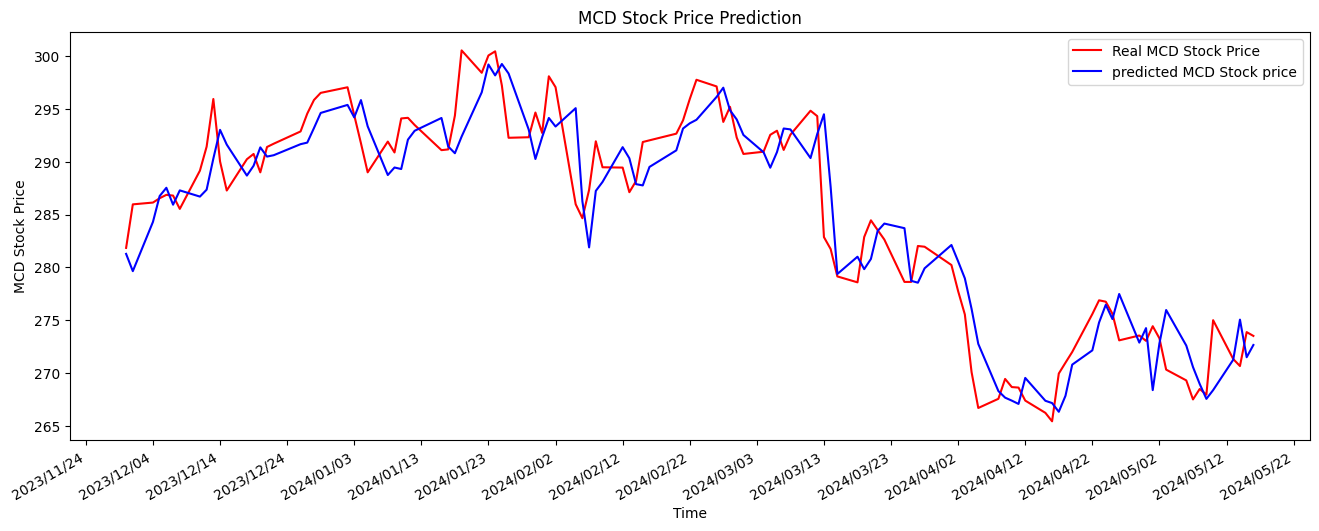

In [21]:
#Visualize the predict result
plt.figure(figsize=(16,6))
plt.plot(pva.index, y_val ,color='red', label="Real MCD Stock Price")
plt.plot(pva.index, y_pred, color="blue", label="predicted MCD Stock price")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))
plt.gcf().autofmt_xdate()
plt.title("MCD Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("MCD Stock Price")
plt.legend()
plt.show()

In [22]:
# Performance metrics [GRU]
MSE = mean_squared_error(y_val, y_pred)
MAE = mean_absolute_error(y_val, y_pred)
r_square = r2_score(y_val, y_pred)
print(f"Mean Square Error = {MSE}")
print(f"Mean Absolute Error = {MAE}")
print(f"R-squared value = {r_square}")

Mean Square Error = 10.87265692064378
Mean Absolute Error = 2.581788950952991
R-squared value = 0.8889119225942164
